In [209]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [210]:
df=pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [211]:
df['output'].value_counts()

1    165
0    138
Name: output, dtype: int64

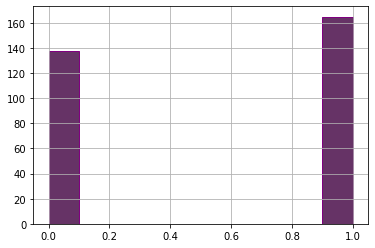

In [212]:
df['output'].hist(color = '#663366', edgecolor = 'purple');

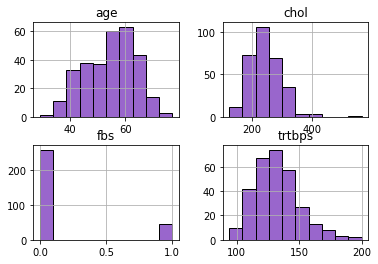

In [213]:
df[['age','chol','fbs','trtbps']].hist(color ='#9966CC' , edgecolor = 'black');

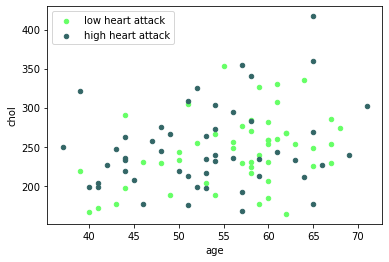

In [214]:
ax = df[df['output'] == 0][0:50].plot(kind='scatter', x='age', y='chol', color='#66FF66', label='low heart attack');
df[df['output'] == 1][0:50].plot(kind='scatter', x='age', y='chol', color='#336666', label='high heart attack', ax=ax);
plt.show()

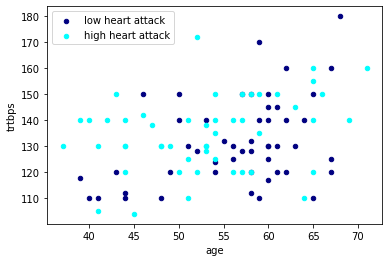

In [215]:
ax = df[df['output'] == 0][0:50].plot(kind='scatter', x='age', y='trtbps', color='Navy', label='low heart attack');
df[df['output'] == 1][0:50].plot(kind='scatter', x='age', y='trtbps', color='Aqua', label='high heart attack', ax=ax);
plt.show()

In [216]:
df.dtypes

age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exng          int64
oldpeak     float64
slp           int64
caa           int64
thall         int64
output        int64
dtype: object

In [217]:
x=np.array(df[['age','sex','cp','trtbps','chol','fbs','restecg','thalachh','exng','oldpeak','slp','caa','thall']])
x[0:5]

array([[ 63. ,   1. ,   3. , 145. , 233. ,   1. ,   0. , 150. ,   0. ,
          2.3,   0. ,   0. ,   1. ],
       [ 37. ,   1. ,   2. , 130. , 250. ,   0. ,   1. , 187. ,   0. ,
          3.5,   0. ,   0. ,   2. ],
       [ 41. ,   0. ,   1. , 130. , 204. ,   0. ,   0. , 172. ,   0. ,
          1.4,   2. ,   0. ,   2. ],
       [ 56. ,   1. ,   1. , 120. , 236. ,   0. ,   1. , 178. ,   0. ,
          0.8,   2. ,   0. ,   2. ],
       [ 57. ,   0. ,   0. , 120. , 354. ,   0. ,   1. , 163. ,   1. ,
          0.6,   2. ,   0. ,   2. ]])

In [218]:
y=np.array(df['output'])
y[0:5]

array([1, 1, 1, 1, 1], dtype=int64)

## Train/Test dataset

In [219]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=4)
print ('Train set:', x_train.shape,  y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (242, 13) (242,)
Test set: (61, 13) (61,)


## Modeling (SVM with Scikit-learn)


In [220]:
from sklearn import svm
model = svm.SVC(kernel='linear')
model.fit(x_train, y_train) 

SVC(kernel='linear')

In [221]:
yhat= model.predict(x_test)
yhat[0:5]

array([1, 0, 1, 1, 1], dtype=int64)

## Evaluation

In [222]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

In [223]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.pink_r):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        25
           1       0.92      0.94      0.93        36

    accuracy                           0.92        61
   macro avg       0.92      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61

Confusion matrix, without normalization
[[34  2]
 [ 3 22]]


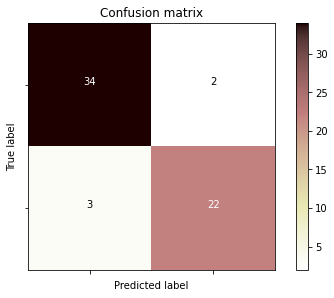

In [224]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['',''],normalize= False,  title='Confusion matrix')

In [225]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted') 

0.9177578060193311

In [226]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat,pos_label=1)

0.8717948717948718